In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# golden rule
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 266kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.3MB/s]


In [ ]:
class FashionModel(nn.Module):
    def __init__(self):
        super(FashionModel, self).__init__()
        # Flattens the 28x28 image into a single dimension (784)
        self.flatten = nn.Flatten()
        # First layer: 784 inputs -> 512 neurons
        self.fc1 = nn.Linear(784, 512)
        # Second layer: 512 -> 256 neurons
        self.fc2 = nn.Linear(512, 256)
        # Output layer: 256 -> 10 classes (t-shirt, shoe, etc.)
        self.fc3 = nn.Linear(256, 10)
        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the model
model = FashionModel()
print(model)

FashionModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Starting training...
Epoch 1/20 - Train Loss: 0.9989 - Val Loss: 0.6280
Epoch 2/20 - Train Loss: 0.5580 - Val Loss: 0.5307
Epoch 3/20 - Train Loss: 0.4891 - Val Loss: 0.4890
Epoch 4/20 - Train Loss: 0.4542 - Val Loss: 0.4853
Epoch 5/20 - Train Loss: 0.4303 - Val Loss: 0.4496
Epoch 6/20 - Train Loss: 0.4122 - Val Loss: 0.4244
Epoch 7/20 - Train Loss: 0.3977 - Val Loss: 0.4294
Epoch 8/20 - Train Loss: 0.3850 - Val Loss: 0.4104
Epoch 9/20 - Train Loss: 0.3744 - Val Loss: 0.3941
Epoch 10/20 - Train Loss: 0.3634 - Val Loss: 0.4177
Epoch 11/20 - Train Loss: 0.3557 - Val Loss: 0.4016
Epoch 12/20 - Train Loss: 0.3469 - Val Loss: 0.3776
Epoch 13/20 - Train Loss: 0.3389 - Val Loss: 0.3752
Epoch 14/20 - Train Loss: 0.3323 - Val Loss: 0.3869
Epoch 15/20 - Train Loss: 0.3258 - Val Loss: 0.3758
Epoch 16/20 - Train Loss: 0.3198 - Val Loss: 0.3863
Epoch 17/20 - Train Loss: 0.3139 - Val Loss: 0.3561
Epoch 18/20 - Train Loss: 0.3079 - Val Loss: 0.3643
Epoch 19/20 - Train Loss: 0.3019 - Val Loss: 0.3583


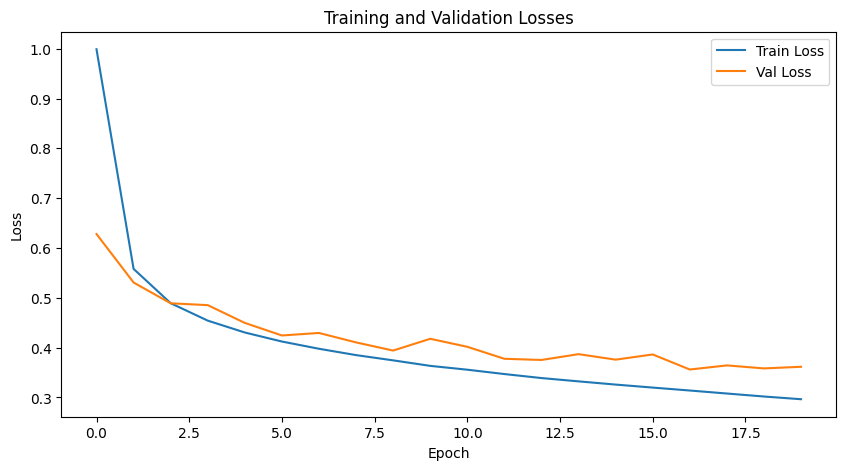

In [ ]:
import matplotlib.pyplot as plt

# Lists to store history for plotting
train_losses = []
val_losses = []

epochs = 20

print("Starting training...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()   # Reset gradients
        outputs = model(images) # Forward pass (make prediction)
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()         # Backward pass (Backpropagation)
        optimizer.step()        # Update weights

        running_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode
    v_loss = 0.0
    with torch.no_grad(): # Disable gradient calculation
        for v_images, v_labels in val_loader:
            v_outputs = model(v_images)
            v_loss += criterion(v_outputs, v_labels).item()

    # Save average losses for the current epoch
    train_losses.append(running_loss / len(train_loader))
    val_losses.append(v_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Val Loss: {val_losses[-1]:.4f}")

print("Training complete!")

# --- PLOTTING ---
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()